In [9]:
# Import Lib
from typing import Tuple, List, Dict, Any
from dataclasses import dataclass, field

import os
import json
import itertools
import mne
import numpy as np
import scipy.io as spio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from pathlib import Path
from tqdm.notebook import tqdm
from joblib import Parallel, delayed
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from eeg_positions import get_elec_coords
from mne.stats import permutation_cluster_1samp_test

In [ ]:
# Set param config
@dataclass
class Config:
    n_channels: int = 63
    n_times_vp: int = 1701
    n_times_vi: int = 3401
    n_conditions: int = 12
    max_n_trials: int = 80
    sfreq: float = 1000
    bin_size: int = 20

    path: str = "data/PreprocData"
    montage_name: str = "1005"

    def __post_init__(self):
        self.path = Path(self.path)

    fp_channels: List[str] = field(
        default_factory=lambda: [
            "Fp1", "Fp2", "AF7", "AF3", "AFz", "AF4", "AF8",
            "F7", "F5", "F3", "F1", "F2", "F4", "F6", "F8",
            "FT9", "FT7", "FC5", "FC3", "FC1", "FCz", "FC2", "FC4", "FC6", "FT8", "FT10",
            "T7", "C5", "C3", "C1", "Cz", "C2", "C4", "C6", "T8",
        ]
    )
    po_channels: List[str] = field(
        default_factory=lambda: [
            "T7", "C5", "C3", "C1", "Cz", "C2", "C4", "C6", "T8",
            "TP9", "TP7", "CP5", "CP3", "CP1", "CPz", "CP2", "CP4", "CP6", "TP8", "TP10",
            "P7", "P5", "P3", "P1", "Pz", "P2", "P4", "P6", "P8",
            "PO7", "PO3", "POz", "PO4", "PO8", "O1", "Oz", "O2",
        ]
    )

config = Config()
# Subject list
subjects = sorted(os.listdir(config.path))[1:]

In [3]:
# Load EEG Montage & Ch Names
montage = montage = mne.channels.read_dig_fif(config.path.parent / "montage-dig.fif")
ch_names = json.load(open(config.path.parent / "ch_names.json"))

In [5]:
# Channel Selection
# - fp_indices: anterior (전두-두정엽)
# - po_indices: posterior (두정-후두엽)
fp_indices = [ch_names.index(ch) for ch in config.fp_channels if ch in ch_names]
po_indices = [ch_names.index(ch) for ch in config.po_channels if ch in ch_names]

# 누락 채널 확인 (Check for missing channels)
fp_missing = [ch for ch in config.fp_channels if ch not in ch_names]
po_missing = [ch for ch in config.po_channels if ch not in ch_names]
print("anterior 누락 :", fp_missing if fp_missing else "없음")
print("posterior 누락:", po_missing if po_missing else "없음")

# 개수/중복/합집합 점검 (논문: 35 / 37 / 공통 9 / 합집합 63)
# - Number of anterior channels
# - Number of posterior channels
# - Commonness channels
# - Union Channels
print(f"anterior  : {len(fp_indices)}개 (paper 35)")
print(f"posterior : {len(po_indices)}개 (paper 37)")
print(f"공통(C/T) : {len(set(fp_indices) & set(po_indices))}개 (paer 9)")
print(f"합집합    : {len(set(fp_indices) | set(po_indices))}개 (paper 63)")

anterior 누락 : 없음
posterior 누락: 없음
anterior  : 35개 (paper 35)
posterior : 37개 (paper 37)
공통(C/T) : 9개 (paer 9)
합집합    : 63개 (paper 63)


In [7]:
# All class combinations
# Number of binary classification experiments that can be combined into 12 classes
classes = np.arange(12)
all_combinations = list(itertools.combinations(classes, 2)) # 66
n_pairs = len(all_combinations)
print(f"실험 조합 개수.: {n_pairs}")

실험 조합 개수.: 66


## 수정 요약 (baseline 학습 제외 + 모델 교체)

**1) baseline(-200~0ms) 처리 = 토글 (`INCLUDE_BASELINE_IN_TRAIN`)**</br>
- `True`(기본): 전 구간 학습 → **논문 Figure 1 재현**(baseline 영역도 chance 근처 패턴으로 채워짐, NaN 없음).
- `False`: 아래처럼 baseline은 test 전용
- 학습(fit)은 task 구간에서만: perception `bins[10:]`, imagery `bins[10:]` (앞 `N_BASELINE_BINS=10`개 = 200ms 제외).
- baseline bin은 test 시점으로만 채워져 시각화 범위(-0.2~0.8 / -0.2~2.5)는 그대로 유지.
- time-generalization + 양방향 평균 구조상:
  - **task×task**: 양방향(P→I, I→P) 평균
  - **baseline(한 축)**: 반대 축이 task일 때 그 한 방향의 test로만 채워짐
  - **baseline×baseline corner**: 어느 방향에서도 학습이 없어 정의 불가 → `NaN`(그룹 검정에서 chance로 대체되어 제외됨)

**2) 모델 교체 지원**
- 기존 `w·x+b` tensordot 경로는 선형 SVM 전용 → `make_clf()` 팩토리 + 일반 `predict` 경로 추가.
- **`make_clf()` 함수만 바꾸면** KNN / MLP 등으로 교체 가능(선형 SVC면 자동으로 빠른 경로 사용).

> posterior만 보려면 **셀 5에서 `ch_mask = np.array(sorted(po_indices))`로 바꾸고 셀 7을 다시 실행**하는 편이 간단합니다.

In [10]:
# ---- band 패턴 축약 + pseudo-trial 유틸 ----
freqs = np.logspace(np.log10(5), np.log10(31), 20)   # 전처리와 동일 (5~31Hz, 20 bins)

# 논문 분할: 20 bins를 '개수'로 나눔 (값 임계 아님)
#   theta = bins 0-4   (5.00 ~ 7.34 Hz, 5개)
#   alpha = bins 5-10  (8.08 ~ 13.06 Hz, 6개)   <- 분석 대상
#   beta  = bins 11-19 (14.38 ~ 31.0 Hz, 9개)
band_bins = {"theta": slice(0, 5), "alpha": slice(5, 11), "beta": slice(11, 20)}
band = "alpha"
freq_sel = band_bins[band]          # = (freqs>=8)&(freqs<14) 와 동일

# 채널 선택: 기본 = 전체 채널 (그림 1F, 메인 cross-MVPA)
ch_mask = np.arange(len(ch_names))
# 그림 1G(국소화, posterior)를 재현하려면 아래 한 줄로 교체:
# ch_mask = np.array(sorted(po_indices))
# ch_mask = np.array(sorted(fp_indices))

# ===== baseline 처리 설정 ============================================
# 앞 N개 bin(= N*20ms)을 baseline으로 정의 (perception/imagery 각각 -200~0ms = 10개 bin).
N_BASELINE_BINS = 10
# baseline을 학습에도 쓸지 여부:
#   True  → 전 구간 학습(논문 Figure 1 재현: baseline 영역에도 chance 근처 패턴이 채워짐)
#   False → baseline은 test 전용(그 영역은 한 방향만/ corner는 NaN)
INCLUDE_BASELINE_IN_TRAIN = True
# =====================================================================

def to_band_pattern(datas):
    """각 조건 (n_trials, n_ch, n_freq, n_time) -> (n_trials, n_ch_sel, n_time), band 평균."""
    return [d[:, ch_mask][:, :, freq_sel].mean(axis=2) for d in datas]

def to_band_pattern_feat(datas):
    """각 조건 (n_trials, n_ch, n_freq, n_time) -> (n_trials, n_ch_sel, n_time), band는 feature에 통합."""
    return [d[:, ch_mask][:, :, freq_sel].reshape(-1, d.shape[1] * len(freqs[freq_sel]), d.shape[-1]) for d in datas]

def make_pseudo(x, n_pseudo, rng):
    """한 조건 trial을 n_pseudo 그룹(각 ~25%)으로 무작위 분할 후 평균.
    x: (n_trials, n_ch, n_time) -> (n_pseudo, n_ch, n_time)"""
    idx = rng.permutation(x.shape[0])
    return np.stack([x[g].mean(0) for g in np.array_split(idx, n_pseudo)], 0)

def train_time_index(n_bins, n_baseline=N_BASELINE_BINS, include_baseline=None):
    """학습에 쓸 시점 인덱스.
    include_baseline=True  → 전 구간 [0:n_bins] (baseline 포함, 논문 재현)
    include_baseline=False → task 구간 [n_baseline:n_bins] (baseline은 test 전용)
    None이면 전역 INCLUDE_BASELINE_IN_TRAIN 사용."""
    if include_baseline is None:
        include_baseline = INCLUDE_BASELINE_IN_TRAIN
    return np.arange(n_bins) if include_baseline else np.arange(n_baseline, n_bins)


In [11]:
# ---- 분류기 팩토리: 모델을 바꾸려면 여기만 수정 ----
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier

def make_clf(svm_c=1.0):
    """새 분류기 인스턴스를 반환. sklearn 호환(fit/predict) 모델이면 무엇이든 가능."""
    return SVC(kernel="linear", C=svm_c)                       # 논문: 선형 SVM
    # 예) KNN:
    # return make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=3))
    # 예) MLP:
    # return make_pipeline(StandardScaler(),
    #                      MLPClassifier(hidden_layer_sizes=(64,), max_iter=500))
    # 예) CNN 등 PyTorch 모델은 skorch로 감싸 sklearn 인터페이스를 맞추면 그대로 동작.


def _is_linear_svc(clf):
    return isinstance(clf, SVC) and clf.kernel == "linear"


def fit_and_score_all_times(X_train, y_train, X_test, y_test,
                            train_time_idx=None, clf_factory=make_clf):
    """
    X_train: (n_trials_train, n_ch, n_times_train)
    X_test : (n_trials_test,  n_ch, n_times_test)
    train_time_idx: 학습에 사용할 train 시점 인덱스(None이면 전체).
                    baseline 제외 시 여기에 task 시점만 넘긴다.

    각 train 시점에서 분류기를 1번 fit하고, 모든 test 시점을 스코어링.
    - 선형 SVC: w,b로 tensordot 해서 빠르게 계산(기존 최적화 경로).
    - 그 외 모델(KNN/MLP/CNN 등): test 시점을 펼쳐 predict 1회 호출.

    반환: (len(train_time_idx), n_times_test) 정확도 행렬.
    """
    if train_time_idx is None:
        train_time_idx = np.arange(X_train.shape[-1])

    n_test = X_test.shape[-1]
    n_tr   = X_test.shape[0]
    n_ch   = X_test.shape[1]
    acc = np.zeros((len(train_time_idx), n_test))

    fast_linear = _is_linear_svc(clf_factory())

    if not fast_linear:
        # (n_trials, n_ch, n_test) -> (n_trials*n_test, n_ch) : predict 1회용
        X_test_flat = np.transpose(X_test, (0, 2, 1)).reshape(-1, n_ch)

    for i, t in enumerate(train_time_idx):
        clf = clf_factory()
        clf.fit(X_train[:, :, t], y_train)

        if fast_linear:
            w = clf.coef_[0]                                   # (n_ch,)
            b = clf.intercept_[0]                              # scalar
            decision = np.tensordot(w, X_test, axes=([0], [1])) + b
            preds = np.where(decision > 0, clf.classes_[1], clf.classes_[0])
        else:
            preds = clf.predict(X_test_flat).reshape(n_tr, n_test)

        acc[i, :] = (preds == y_test[:, None]).mean(axis=0)

    return acc


def one_permutation(seed):
    rng = np.random.default_rng(seed)
    Pp = [make_pseudo(per_band[c], n_pseudo, rng) for c in range(config.n_conditions)]
    Ip = [make_pseudo(img_band[c], n_pseudo, rng) for c in range(config.n_conditions)]

    # sum/count로 누적: task 구간에서만 학습하므로 방향별 커버 범위가 다르다.
    #   방향 P→I : perception=task(행), imagery=full(열)
    #   방향 I→P : imagery=task(열),  perception=full(행)
    # → task×task는 양방향 평균, baseline은 한쪽 방향(테스트)만, baseline×baseline은 미정(NaN).
    acc_sum = np.zeros((n_tp, n_ti))
    acc_cnt = np.zeros((n_tp, n_ti))
    all_ti = np.arange(n_ti)
    all_tp = np.arange(n_tp)

    for c1, c2 in all_combinations:                          # 66개 쌍 모두
        X_P = np.concatenate([Pp[c1], Pp[c2]], axis=0)       # (2*n_pseudo, n_ch, n_tp)
        X_I = np.concatenate([Ip[c1], Ip[c2]], axis=0)       # (2*n_pseudo, n_ch, n_ti)

        # train P(task) -> test I(full): (len(tp_train), n_ti)
        s_pi = fit_and_score_all_times(X_P, y, X_I, y, train_time_idx=tp_train_idx,
                                       clf_factory=lambda: make_clf(svm_c))
        # train I(task) -> test P(full): (len(ti_train), n_tp)
        s_ip = fit_and_score_all_times(X_I, y, X_P, y, train_time_idx=ti_train_idx,
                                       clf_factory=lambda: make_clf(svm_c))

        # 방향 P→I: perception=task 행에만 누적
        acc_sum[np.ix_(tp_train_idx, all_ti)] += s_pi
        acc_cnt[np.ix_(tp_train_idx, all_ti)] += 1.0
        # 방향 I→P: imagery=task 열에만 누적(전치)
        acc_sum[np.ix_(all_tp, ti_train_idx)] += s_ip.T
        acc_cnt[np.ix_(all_tp, ti_train_idx)] += 1.0

    with np.errstate(invalid="ignore"):
        acc = acc_sum / acc_cnt        # 커버 안 된 baseline×baseline corner = 0/0 = NaN
    return acc


In [12]:
n_pseudo = 4
n_perm   = 100        # 논문: 100. 빠른 점검은 20 정도로 줄여도 됨.
svm_c    = 1.0        # 논문: 선형 SVM, C=1

score_matrix_list = []
pbar = tqdm(subjects)
for subject in pbar:
    pbar.set_description(f"Processing {subject}")

    # Data Load
    loaded = np.load(config.path / subject / "preprocess.npy", allow_pickle=True).item()
    per_datas = loaded["eeg"]["per"]
    img_datas = loaded["eeg"]["img"]
    per_labels_list = loaded["label"]["per"]
    img_labels_list = loaded["label"]["img"]

    # if per_datas[0].shape[0] < 80 or img_datas[0].shape[0] < 80:
    #     print(f"⚠️ {subject} has insufficient trials for pseudo-trial creation. Skipping.")
    #     continue

    per_band = to_band_pattern(per_datas)
    img_band = to_band_pattern(img_datas)

    n_tp = per_band[0].shape[-1]
    n_ti = img_band[0].shape[-1]
    y = np.r_[np.zeros(n_pseudo), np.ones(n_pseudo)]   # 쌍 내 0/1 레이블

    # ===== 학습 구간(baseline 제외) 인덱스 =====
    #   앞 N_BASELINE_BINS개 bin은 test로만 쓰이고 학습에서 빠진다.
    tp_train_idx = train_time_index(n_tp)   # perception: bins [10:]
    ti_train_idx = train_time_index(n_ti)   # imagery:    bins [10:]

    perm_results = Parallel(n_jobs=-1)(
        delayed(one_permutation)(42 + k) for k in range(n_perm)
    )
    mean_score_matrix = np.mean(perm_results, axis=0)
    score_matrix_list.append(mean_score_matrix)

# 첫 피험자 기준 학습/테스트 구간 요약 출력
print(f"perception: 전체 {n_tp} bins → 학습 {len(tp_train_idx)} bins(baseline {N_BASELINE_BINS} 제외)")
print(f"imagery   : 전체 {n_ti} bins → 학습 {len(ti_train_idx)} bins(baseline {N_BASELINE_BINS} 제외)")


  0%|          | 0/36 [00:00<?, ?it/s]

perception: 전체 50 bins → 학습 50 bins(baseline 10 제외)
imagery   : 전체 135 bins → 학습 135 bins(baseline 10 제외)


In [13]:
n_perm = 10000

# ── 1. 데이터 준비 ────────────────────────────────────────
# score_matrix_list: list of (n_tp, n_ti) matrices, 길이 = n_subjects
X = np.stack(score_matrix_list, axis=0)   # shape: (n_subjects, n_tp, n_ti)

# baseline×baseline corner는 학습 자체가 없어 NaN → chance(0.5)로 채움.
# (centered=0이 되어 one-tailed 클러스터 검정에 기여하지 않음 = 관심 영역에서 제외)
X = np.nan_to_num(X, nan=0.5)

# chance level(0.5)을 빼서 "0으로부터의 편차"로 변환
X_centered = X - 0.5

# ── 2. Cluster-based permutation test ────────────────────
# threshold: 클러스터 형성 기준이 되는 t-value 임계값 (None이면 자동으로 alpha=0.05 기준 산출)
t_obs, clusters, cluster_pv, H0 = permutation_cluster_1samp_test(
    X_centered,
    n_permutations=n_perm,     # 논문 스타일: 1000회 이상 권장
    threshold=None,          # None -> 자동으로 df 기반 t 임계값 사용 (alpha=0.05 양측)
    tail=1,                  # decoding acc는 chance보다 "높은" 방향만 보므로 one-tailed (1)
    n_jobs=-1,
    seed=42,
    out_type='mask'          # boolean mask 형태로 반환 (그리기 편함)
)

# ── 3. 유의한 클러스터만 마스크로 합치기 ───────────────────
sig_mask = np.zeros_like(t_obs, dtype=bool)
for c, p in zip(clusters, cluster_pv):
    if p < 0.05 / 3:              # cluster-level 유의수준
        sig_mask |= c         # out_type='mask'이면 c 자체가 boolean mask

# ── 4. Plotting: 행렬 + 유의 영역 검은 외곽선 ──────────────
mean_matrix = X.mean(axis=0)   # group-level 평균 accuracy matrix
plot_matrix = mean_matrix.T           # x=Perception, y=Imagery로 맞추기 위해 transpose
plot_mask   = sig_mask.T

Using a threshold of 1.689572
stat_fun(H1): min=-2.04393810770532 max=3.8059726077354514
Running initial clustering …
Found 13 clusters


  0%|          | Permuting : 0/9999 [00:00<?,       ?it/s]

In [14]:
for c, p in zip(clusters, cluster_pv):
    # 해당 cluster가 몇 ms~몇 ms에 걸쳐 있는지, p값이 얼마인지 출력
    print(f"cluster p={p:.4f}, size={c.sum()}, "
          f"time range≈{np.where(c.any(axis=1))[0].min()}~{np.where(c.any(axis=1))[0].max()} bins")

cluster p=0.7478, size=20, time range≈0~3 bins
cluster p=0.7833, size=17, time range≈0~3 bins
cluster p=0.2445, size=186, time range≈0~12 bins
cluster p=0.7487, size=22, time range≈1~4 bins
cluster p=0.9001, size=1, time range≈1~1 bins
cluster p=0.7225, size=27, time range≈1~6 bins
cluster p=0.1112, size=354, time range≈10~49 bins
cluster p=0.6162, size=48, time range≈16~22 bins
cluster p=0.0063, size=1595, time range≈17~49 bins
cluster p=0.5753, size=55, time range≈25~36 bins
cluster p=0.9039, size=1, time range≈28~28 bins
cluster p=0.6310, size=41, time range≈33~41 bins
cluster p=0.4666, size=85, time range≈41~49 bins


In [15]:
if True in np.unique(plot_mask):
    print("✅ 유효한 값이 확인되었습니다.")
else:
    print("❌ 유효한 값이 확인되지 않았습니다.")

✅ 유효한 값이 확인되었습니다.


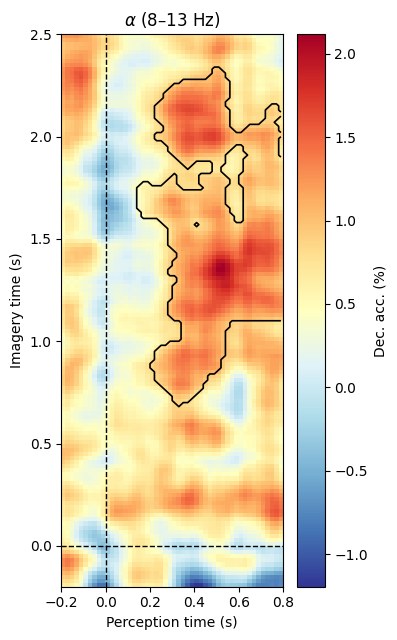

In [17]:
# extent는 직접 지정: [Perception_min, Perception_max, Imagery_min, Imagery_max]
extent = [-0.2, 0.8, -0.2, 2.5]   # ← 실제 시간 범위에 맞게 수정

# baseline/onset 구분선 (자극 제시 시점 = 0s)
perception_onset = 0.0
imagery_onset    = 0.0

fig, ax = plt.subplots(figsize=(4, 6.5))

im = ax.imshow(
    (plot_matrix*100)-50, origin='lower', aspect='auto',
    extent=extent, cmap='RdYlBu_r'
)
ax.set_xlabel('Perception time (s)')
ax.set_ylabel('Imagery time (s)')
plt.colorbar(im, ax=ax, label='Dec. acc. (%)')

# ── baseline 구분 점선 (검은 dashed line) ──────────────────
ax.axvline(perception_onset, color='black', linestyle='--', linewidth=1)
ax.axhline(imagery_onset,    color='black', linestyle='--', linewidth=1)

# ── 유의 영역 외곽선 (검은 실선) ────────────────────────────
ax.contour(
    plot_mask.astype(float),
    levels=[0.5],
    colors='black',
    linewidths=1.2,
    extent=extent,
    origin='lower'
)

if band == "theta":
    ax.set_title(r'$\theta$ (5–7 Hz)')
if band == "alpha":
    ax.set_title(r'$\alpha$ (8–13 Hz)')
else: # band == "beta"
    ax.set_title(r'$\beta$ (14–31 Hz)')
plt.tight_layout()
plt.show()